# PIPELINE COMPLETO - EDA, Preprocesamiento, Entrenamiento y Evaluación

Este cuaderno combina:
- 01_eda_preprocessing: Análisis exploratorio, limpieza y preparación de datos
- 02_train_evaluate: Entrenamientos con redes neuronales, evaluación y robustez

Detección de malware Android en modalidad tabular

# PARTE 1: EDA Y PREPROCESAMIENTO

## 0. Importar Librerías

In [4]:
%pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl.metadata (59 kB)
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 3.1 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached numpy-2.0.2-cp312-cp312-win_amd64.whl (15.6 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.0.2 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.0.2 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score, 
    accuracy_score
)
from sklearn.inspection import permutation_importance

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks

# SHAP
import shap

# Configuración
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print(f'TensorFlow version: {tf.__version__}')
print(f'SHAP version: {shap.__version__}')
print('✓ Librerías importadas')

TensorFlow version: 2.21.0
SHAP version: 0.51.0
✓ Librerías importadas


## 1. Carga y Validación Inicial

In [7]:
# Rutas
data_path = 'Multimodal_CIC-MalDroid2020/Tabular/'

# Cargar datos
df_train = pd.read_csv(f'{data_path}train-tabular.csv')
df_test = pd.read_csv(f'{data_path}test-tabular.csv')

print('TRAIN DATA')
print(f'  Shape: {df_train.shape}')
print(f'  Features: {df_train.shape[1] - 2}')
print(f'  Null values: {df_train.isnull().sum().sum()}')

print('\nTEST DATA')
print(f'  Shape: {df_test.shape}')
print(f'  Null values: {df_test.isnull().sum().sum()}')

# Distribución de clases
print('\nCLASE DISTRIBUTION (TRAIN):')
print(df_train['Class'].value_counts().sort_index())
print('\nCLASE DISTRIBUTION (TEST):')
print(df_test['Class'].value_counts().sort_index())

TRAIN DATA
  Shape: (11683, 402)
  Features: 400
  Null values: 0

TEST DATA
  Shape: (5008, 402)
  Null values: 0

CLASE DISTRIBUTION (TRAIN):
Class
adware      1061
banking     1733
benign      2821
riskware    2727
sms         3341
Name: count, dtype: int64

CLASE DISTRIBUTION (TEST):
Class
adware       450
banking      720
benign      1209
riskware    1165
sms         1464
Name: count, dtype: int64


## 2. Análisis Exploratorio Univariado

In [8]:
# Separar features de etiquetas
feature_cols = [col for col in df_train.columns if col not in ['apk_name', 'Class']]
print(f'Total de features: {len(feature_cols)}')
print(f'Primeras 10: {feature_cols[:10]}')

X_train = df_train[feature_cols].copy()
y_train = df_train['Class'].copy()
X_test = df_test[feature_cols].copy()
y_test = df_test['Class'].copy()

# Análisis de sparsity
print('\nSPARSITY ANALYSIS:')
zeros_per_feature = (X_train == 0).sum() / len(X_train) * 100
print(f'  Media de ceros: {zeros_per_feature.mean():.2f}%')
print(f'  Min: {zeros_per_feature.min():.2f}%, Max: {zeros_per_feature.max():.2f}%')

# Variables constantes
constant_features = X_train.columns[X_train.var() == 0].tolist()
print(f'\nVariables constantes (var=0): {len(constant_features)}')
if constant_features:
    print(f'  Ejemplos: {constant_features[:5]}')

# Variables quasi-constantes (baja varianza)
quasi_const = X_train.columns[X_train.var() < 0.01].tolist()
print(f'\nVariables quasi-constantes (var<0.01): {len(quasi_const)}')

Total de features: 400
Primeras 10: ['permission.CALL_PHONE', 'permission.INTERNET', 'permission.READ_EXTERNAL_STORAGE', 'permission.READ_PHONE_STATE', 'permission.WRITE_EXTERNAL_STORAGE', 'permission.WRITE_SMS', 'permission.INSTALL_SHORTCUT', 'permission.C2D_MESSAGE', 'permission.ACCESS_NETWORK_STATE', 'permission.RECEIVE_BOOT_COMPLETED']

SPARSITY ANALYSIS:
  Media de ceros: 96.88%
  Min: 1.51%, Max: 100.00%

Variables constantes (var=0): 19
  Ejemplos: ['MyLocationService', 'action.SEND_TO_KPSH', 'MvService', 'action.LOCKER_ACTIVE', 'action.widget.click']

Variables quasi-constantes (var<0.01): 323


## 3. Análisis de Correlaciones y Redundancia

Calculando matriz de correlación...

Pares altamente correlacionados (corr > 0.95): 49

Primeros 10 ejemplos:
  permission.WRITE_INTERNAL_STORAGE <-> permission.READ_INTERNAL_STORAGE: 0.9647
  action.NOTIFICATION_REMOVE <-> action.STATE_CHANGED: 0.9579
  action.NOTIFICATION_REMOVE <-> action.ANY_DATA_STATE: 0.9695
  action.NOTIFICATION_REMOVE <-> action.NOTIFICATION_ADD: 0.9920
  action.STATE_CHANGED <-> action.ANY_DATA_STATE: 0.9727
  action.STATE_CHANGED <-> action.NOTIFICATION_ADD: 0.9657
  permission.SEND_RESPOND_VIA_MESSAGE <-> action.RESPOND_VIA_MESSAGE: 0.9871
  action.ANY_DATA_STATE <-> action.NOTIFICATION_ADD: 0.9765
  permission.BROADCAST_PACKAGE_ADDED <-> permission.BROADCAST_PACKAGE_INSTALL: 0.9852
  permission.BROADCAST_PACKAGE_ADDED <-> permission.BROADCAST_PACKAGE_REPLACED: 0.9706


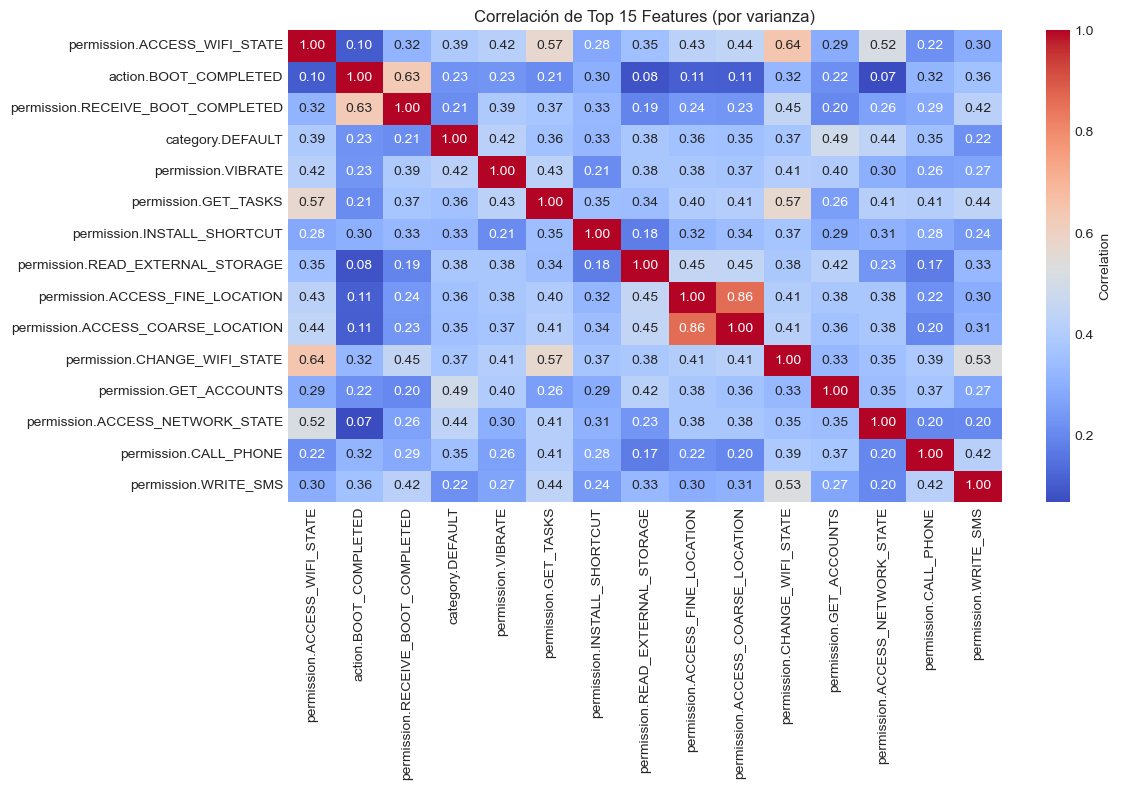

✓ Figura guardada: reports/01_correlation_matrix.png


In [9]:
# Matriz de correlación (sample para visualización)
print('Calculando matriz de correlación...')
corr_matrix = X_train.corr()

# Variables altamente correlacionadas
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.95:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f'\nPares altamente correlacionados (corr > 0.95): {len(high_corr_pairs)}')
if high_corr_pairs:
    print('\nPrimeros 10 ejemplos:')
    for feat1, feat2, corr_val in high_corr_pairs[:10]:
        print(f'  {feat1} <-> {feat2}: {corr_val:.4f}')

# Visualizar top correlaciones
fig, ax = plt.subplots(figsize=(12, 8))
# Top features por varianza
top_features = X_train.var().nlargest(15).index.tolist()
sns.heatmap(X_train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', ax=ax, cbar_kws={'label': 'Correlation'})
plt.title('Correlación de Top 15 Features (por varianza)')
plt.tight_layout()

# Asegurar que la carpeta reports existe
os.makedirs('reports', exist_ok=True)
plt.savefig('reports/01_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/01_correlation_matrix.png')

## 4. Separabilidad y Visualización PCA

Clases: ['adware' 'banking' 'benign' 'riskware' 'sms']

Aplicando PCA...
Varianza explicada (2 componentes): 0.3532
Varianza explicada (10 componentes): 0.6520
Varianza explicada (50 componentes): 0.9322


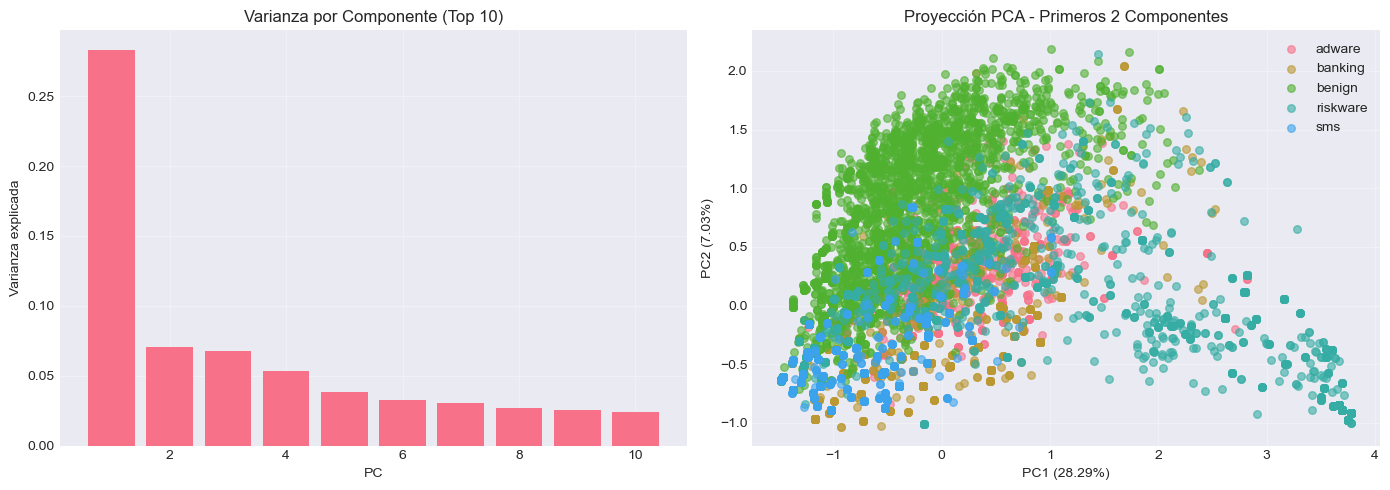

✓ Figura guardada: reports/02_pca_analysis.png


In [10]:
# Codificar clases para PCA
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

class_names = le.classes_
print(f'Clases: {class_names}')

# PCA
print('\nAplicando PCA...')
pca = PCA(n_components=50)
X_train_pca = pca.fit_transform(X_train)

print(f'Varianza explicada (2 componentes): {pca.explained_variance_ratio_[:2].sum():.4f}')
print(f'Varianza explicada (10 componentes): {pca.explained_variance_ratio_[:10].sum():.4f}')
print(f'Varianza explicada (50 componentes): {pca.explained_variance_ratio_[:50].sum():.4f}')

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Varianza explicada
axes[0].bar(range(1, 11), pca.explained_variance_ratio_[:10])
axes[0].set_xlabel('PC')
axes[0].set_ylabel('Varianza explicada')
axes[0].set_title('Varianza por Componente (Top 10)')
axes[0].grid(alpha=0.3)

# Scatter PCA
for i, class_name in enumerate(class_names):
    mask = y_train_encoded == i
    axes[1].scatter(X_train_pca[mask, 0], X_train_pca[mask, 1], 
                   label=class_name, alpha=0.6, s=30)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')
axes[1].set_title('Proyección PCA - Primeros 2 Componentes')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reports/02_pca_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/02_pca_analysis.png')

## 5. Limpieza: Eliminar Features Redundantes

In [11]:
# Eliminar variables constantes
features_to_keep = X_train.columns[(X_train.var() > 0)].tolist()
print(f'Eliminadas constantes: {len(feature_cols) - len(features_to_keep)}')

# Eliminar una variable de cada par altamente correlacionado
# (mantener la con mayor varianza)
remove_set = set()
for feat1, feat2, _ in high_corr_pairs:
    var1 = X_train[feat1].var()
    var2 = X_train[feat2].var()
    remove_set.add(feat2 if var1 > var2 else feat1)

features_to_keep = [f for f in features_to_keep if f not in remove_set]
print(f'Eliminadas por alta correlación: {len(remove_set)}')
print(f'Features finales: {len(features_to_keep)}')

# Aplicar limpieza
X_train = X_train[features_to_keep].copy()
X_test = X_test[features_to_keep].copy()

print(f'\nX_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')

Eliminadas constantes: 19
Eliminadas por alta correlación: 36
Features finales: 345

X_train shape: (11683, 345)
X_test shape: (5008, 345)


## 6. Split Train/Val/Test Estratificado

In [12]:
# Split: Train (70%) + Val (15%) + Test (15%) estratificado
X_temp, X_test_split, y_temp, y_test_split = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=42
)

X_train_split, X_val, y_train_split, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, stratify=y_temp, random_state=42
)

print('SPLIT SIZES:')
print(f'  Train: {X_train_split.shape[0]} ({100*len(X_train_split)/len(X_train):.1f}%)')
print(f'  Val:   {X_val.shape[0]} ({100*len(X_val)/len(X_train):.1f}%)')
print(f'  Test:  {X_test_split.shape[0]} ({100*len(X_test_split)/len(X_train):.1f}%)')

print('\nDISTRIBUCIÓN DE CLASES (TRAIN SPLIT):')
for class_name in class_names:
    count = (y_train_split == class_name).sum()
    pct = 100 * count / len(y_train_split)
    print(f'  {class_name:10s}: {count:5d} ({pct:5.2f}%)')

# Usar test del dataset original como test final
print('\nUsando test original del dataset como TEST FINAL')
X_test_final = X_test
y_test_final = y_test

print(f'Test final shape: {X_test_final.shape}')
print('\nDISTRIBUCIÓN DE CLASES (TEST FINAL):')
for class_name in class_names:
    count = (y_test_final == class_name).sum()
    pct = 100 * count / len(y_test_final)
    print(f'  {class_name:10s}: {count:5d} ({pct:5.2f}%)')

SPLIT SIZES:
  Train: 8182 (70.0%)
  Val:   1748 (15.0%)
  Test:  1753 (15.0%)

DISTRIBUCIÓN DE CLASES (TRAIN SPLIT):
  adware    :   743 ( 9.08%)
  banking   :  1214 (14.84%)
  benign    :  1976 (24.15%)
  riskware  :  1910 (23.34%)
  sms       :  2339 (28.59%)

Usando test original del dataset como TEST FINAL
Test final shape: (5008, 345)

DISTRIBUCIÓN DE CLASES (TEST FINAL):
  adware    :   450 ( 8.99%)
  banking   :   720 (14.38%)
  benign    :  1209 (24.14%)
  riskware  :  1165 (23.26%)
  sms       :  1464 (29.23%)


## 7. Escalado y Normalización

In [13]:
# Escalador
scaler = StandardScaler()

# Fit SOLO en train, luego transform todo
X_train_scaled = scaler.fit_transform(X_train_split)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test_final)

print('ESTADÍSTICAS POST-ESCALADO (Train):')
print(f'  Mean: {X_train_scaled.mean():.6f}')
print(f'  Std:  {X_train_scaled.std():.6f}')
print(f'  Min:  {X_train_scaled.min():.4f}')
print(f'  Max:  {X_train_scaled.max():.4f}')

# Codificar clases
y_train_enc = le.transform(y_train_split)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test_final)

print(f'\nClases codificadas: {dict(zip(class_names, range(len(class_names))))}')

ESTADÍSTICAS POST-ESCALADO (Train):
  Mean: -0.000000
  Std:  0.969087
  Min:  -8.3025
  Max:  90.4489

Clases codificadas: {'adware': 0, 'banking': 1, 'benign': 2, 'riskware': 3, 'sms': 4}


## 8. Guardar Datos Procesados

In [14]:
# Crear carpeta
os.makedirs('data/processed', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# Guardar datos
np.save('data/processed/X_train_scaled.npy', X_train_scaled)
np.save('data/processed/X_val_scaled.npy', X_val_scaled)
np.save('data/processed/X_test_scaled.npy', X_test_scaled)
np.save('data/processed/y_train_enc.npy', y_train_enc)
np.save('data/processed/y_val_enc.npy', y_val_enc)
np.save('data/processed/y_test_enc.npy', y_test_enc)

# Guardar metadatos
metadata = {
    'feature_names': features_to_keep,
    'class_names': class_names,
    'n_features': len(features_to_keep),
    'n_classes': len(class_names),
    'shapes': {
        'X_train': X_train_scaled.shape,
        'X_val': X_val_scaled.shape,
        'X_test': X_test_scaled.shape
    }
}

with open('data/processed/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

# Guardar escalador
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar label encoder
with open('models/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('✓ Datos guardados en data/processed/')
print('✓ Scaler guardado en models/scaler.pkl')
print('✓ Label Encoder guardado en models/label_encoder.pkl')
print(f'\nRESUMEN PREPROCESAMIENTO:')
print(f'  Features originales: 400')
print(f'  Features finales: {len(features_to_keep)}')
print(f'  Reducción: {100*(400-len(features_to_keep))/400:.1f}%')
print(f'  Train samples: {X_train_scaled.shape[0]}')
print(f'  Val samples: {X_val_scaled.shape[0]}')
print(f'  Test samples: {X_test_scaled.shape[0]}')

✓ Datos guardados en data/processed/
✓ Scaler guardado en models/scaler.pkl
✓ Label Encoder guardado en models/label_encoder.pkl

RESUMEN PREPROCESAMIENTO:
  Features originales: 400
  Features finales: 345
  Reducción: 13.8%
  Train samples: 8182
  Val samples: 1748
  Test samples: 5008


# PARTE 2: ENTRENAMIENTO Y EVALUACIÓN CON REDES NEURONALES

## 9. Cargar Datos Procesados

In [15]:
# Cargar datos
X_train = np.load('data/processed/X_train_scaled.npy')
X_val = np.load('data/processed/X_val_scaled.npy')
X_test = np.load('data/processed/X_test_scaled.npy')
y_train = np.load('data/processed/y_train_enc.npy')
y_val = np.load('data/processed/y_val_enc.npy')
y_test = np.load('data/processed/y_test_enc.npy')

# Metadatos
with open('data/processed/metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

feature_names = metadata['feature_names']
class_names = metadata['class_names']
n_features = metadata['n_features']
n_classes = metadata['n_classes']

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape: {X_val.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'\nClases: {class_names}')
print(f'Features: {n_features}')

X_train shape: (8182, 345)
X_val shape: (1748, 345)
X_test shape: (5008, 345)

Clases: ['adware' 'banking' 'benign' 'riskware' 'sms']
Features: 345


## 10. Definir Arquitecturas de Redes Neuronales

In [16]:
def build_model_v1(n_features, n_classes, dropout_rate=0.3):
    """
    Arquitectura V1: 400 -> 256 -> 128 -> 64 -> 5
    Regularización moderada con dropout
    """
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.Dropout(dropout_rate),
        
        layers.Dense(n_classes, activation='softmax')
    ])
    return model

def build_model_v2(n_features, n_classes, dropout_rate=0.2):
    """
    Arquitectura V2: 400 -> 512 -> 256 -> 128 -> 5
    Más profunda y robusta
    """
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
        layers.BatchNormalization(),
        layers.Dropout(dropout_rate),
        
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
        layers.Dropout(dropout_rate),
        
        layers.Dense(n_classes, activation='softmax')
    ])
    return model

print('✓ Arquitecturas definidas')

✓ Arquitecturas definidas


## 11. Entrenar Modelos

In [17]:
# Calcular class weights para manejar desbalance
class_weights_array = compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = dict(enumerate(class_weights_array))

print('CLASS WEIGHTS (para balancear desbalance):')
for class_idx, class_name in enumerate(class_names):
    print(f'  {class_name}: {class_weights[class_idx]:.3f}')

# Entrenar V1
print('\n' + '='*60)
print('ENTRENANDO MODELO V1 (400 -> 256 -> 128 -> 64 -> 5)')
print('='*60)

model_v1 = build_model_v1(n_features, n_classes, dropout_rate=0.3)
model_v1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history_v1 = model_v1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

print(f'✓ V1 entrenado ({len(history_v1.history["loss"])} epochs)')

# Entrenar V2
print('\n' + '='*60)
print('ENTRENANDO MODELO V2 (400 -> 512 -> 256 -> 128 -> 5)')
print('='*60)

model_v2 = build_model_v2(n_features, n_classes, dropout_rate=0.2)
model_v2.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0008),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_v2 = model_v2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=0
)

print(f'✓ V2 entrenado ({len(history_v2.history["loss"])} epochs)')

CLASS WEIGHTS (para balancear desbalance):
  adware: 2.202
  banking: 1.348
  benign: 0.828
  riskware: 0.857
  sms: 0.700

ENTRENANDO MODELO V1 (400 -> 256 -> 128 -> 64 -> 5)
✓ V1 entrenado (45 epochs)

ENTRENANDO MODELO V2 (400 -> 512 -> 256 -> 128 -> 5)
✓ V2 entrenado (15 epochs)


## 12. Comparar Modelos en Validation Set

COMPARACIÓN EN VALIDATION SET:

Modelo V1 (256-128-64):
  Accuracy:      0.8999
  Macro-F1:      0.8830
  Weighted-F1:   0.9004

Modelo V2 (512-256-128):
  Accuracy:      0.8461
  Macro-F1:      0.8256
  Weighted-F1:   0.8499

✓ Mejor modelo: V1


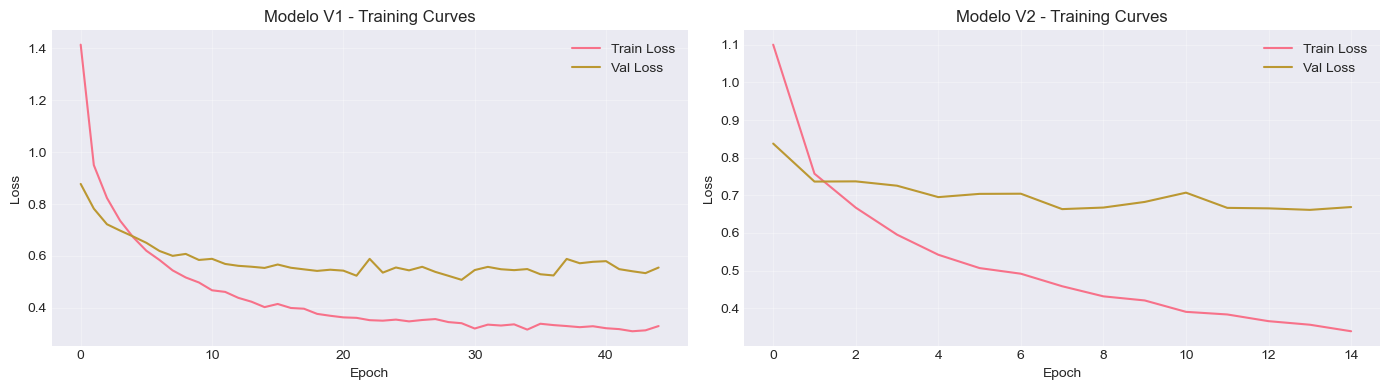

✓ Figura guardada: reports/03_training_curves.png


In [18]:
# Predecir en validation
y_val_pred_v1 = model_v1.predict(X_val, verbose=0).argmax(axis=1)
y_val_pred_v2 = model_v2.predict(X_val, verbose=0).argmax(axis=1)

# Métricas
macro_f1_v1 = f1_score(y_val, y_val_pred_v1, average='macro')
macro_f1_v2 = f1_score(y_val, y_val_pred_v2, average='macro')
weighted_f1_v1 = f1_score(y_val, y_val_pred_v1, average='weighted')
weighted_f1_v2 = f1_score(y_val, y_val_pred_v2, average='weighted')

print('COMPARACIÓN EN VALIDATION SET:')
print('\nModelo V1 (256-128-64):')
print(f'  Accuracy:      {accuracy_score(y_val, y_val_pred_v1):.4f}')
print(f'  Macro-F1:      {macro_f1_v1:.4f}')
print(f'  Weighted-F1:   {weighted_f1_v1:.4f}')

print('\nModelo V2 (512-256-128):')
print(f'  Accuracy:      {accuracy_score(y_val, y_val_pred_v2):.4f}')
print(f'  Macro-F1:      {macro_f1_v2:.4f}')
print(f'  Weighted-F1:   {weighted_f1_v2:.4f}')

# Seleccionar mejor
best_model = model_v2 if macro_f1_v2 >= macro_f1_v1 else model_v1
best_version = 'V2' if macro_f1_v2 >= macro_f1_v1 else 'V1'
print(f'\n✓ Mejor modelo: {best_version}')

# Visualizar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for idx, (history, version) in enumerate([(history_v1, 'V1'), (history_v2, 'V2')]):
    axes[idx].plot(history.history['loss'], label='Train Loss')
    axes[idx].plot(history.history['val_loss'], label='Val Loss')
    axes[idx].set_xlabel('Epoch')
    axes[idx].set_ylabel('Loss')
    axes[idx].set_title(f'Modelo {version} - Training Curves')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('reports/03_training_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/03_training_curves.png')

## 13. Evaluación Final en Test Set

EVALUACIÓN FINAL - TEST SET
Accuracy:      0.9107
Macro-F1:      0.8925 ⭐ (Principal)
Weighted-F1:   0.9118
Micro-F1:      0.9107

REPORTE POR CLASE:
              precision    recall  f1-score   support

      adware       0.72      0.93      0.81       450
     banking       0.90      0.83      0.86       720
      benign       0.90      0.94      0.92      1209
    riskware       0.94      0.87      0.90      1165
         sms       0.97      0.96      0.97      1464

    accuracy                           0.91      5008
   macro avg       0.89      0.90      0.89      5008
weighted avg       0.92      0.91      0.91      5008



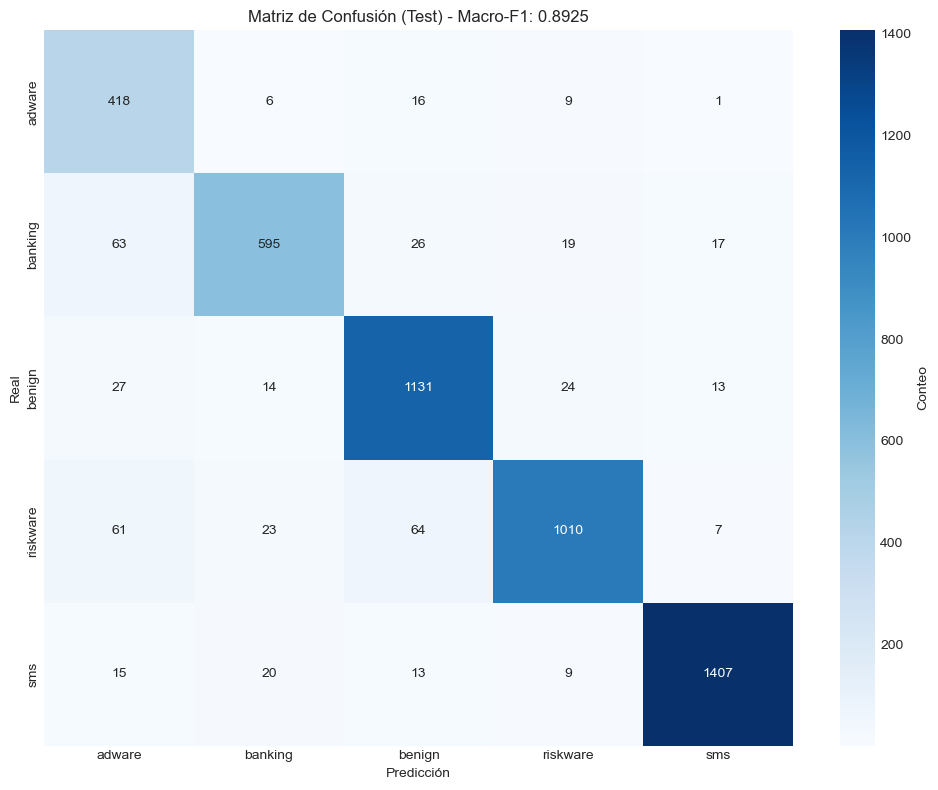

✓ Figura guardada: reports/04_confusion_matrix.png


In [19]:
# Predicciones finales en test
y_test_pred = best_model.predict(X_test, verbose=0).argmax(axis=1)
y_test_proba = best_model.predict(X_test, verbose=0)

# Métricas
accuracy = accuracy_score(y_test, y_test_pred)
macro_f1 = f1_score(y_test, y_test_pred, average='macro')
weighted_f1 = f1_score(y_test, y_test_pred, average='weighted')
micro_f1 = f1_score(y_test, y_test_pred, average='micro')

print('='*60)
print('EVALUACIÓN FINAL - TEST SET')
print('='*60)
print(f'Accuracy:      {accuracy:.4f}')
print(f'Macro-F1:      {macro_f1:.4f} ⭐ (Principal)')
print(f'Weighted-F1:   {weighted_f1:.4f}')
print(f'Micro-F1:      {micro_f1:.4f}')

# Por clase
print('\nREPORTE POR CLASE:')
print(classification_report(y_test, y_test_pred, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=ax,
            cbar_kws={'label': 'Conteo'})
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de Confusión (Test) - Macro-F1: {macro_f1:.4f}')
plt.tight_layout()
plt.savefig('reports/04_confusion_matrix.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/04_confusion_matrix.png')

## 14. Feature Importance - Permutation

Calculando Permutation Importance...

TOP 20 FEATURES (Permutation Importance):
   1. permission.ACCESS_NETWORK_STATE          0.097486
   2. permission.GET_TASKS                     0.074041
   3. permission.READ_PHONE_STATE              0.067135
   4. permission.ACCESS_WIFI_STATE             0.054315
   5. permission.READ_EXTERNAL_STORAGE         0.053712
   6. permission.WRITE_EXTERNAL_STORAGE        0.052474
   7. permission.INSTALL_SHORTCUT              0.043986
   8. action.BOOT_COMPLETED                    0.042009
   9. permission.CALL_PHONE                    0.029894
  10. permission.RECEIVE_BOOT_COMPLETED        0.026225
  11. permission.WRITE_SMS                     0.024519
  12. permission.C2D_MESSAGE                   0.022453
  13. category.DEFAULT                         0.020741
  14. permission.SET_ALARM                     0.016450
  15. permission.GET_ACCOUNTS                  0.014689
  16. permission.ACCESS_COARSE_LOCATION        0.014641
  17. permission.ACCESS_

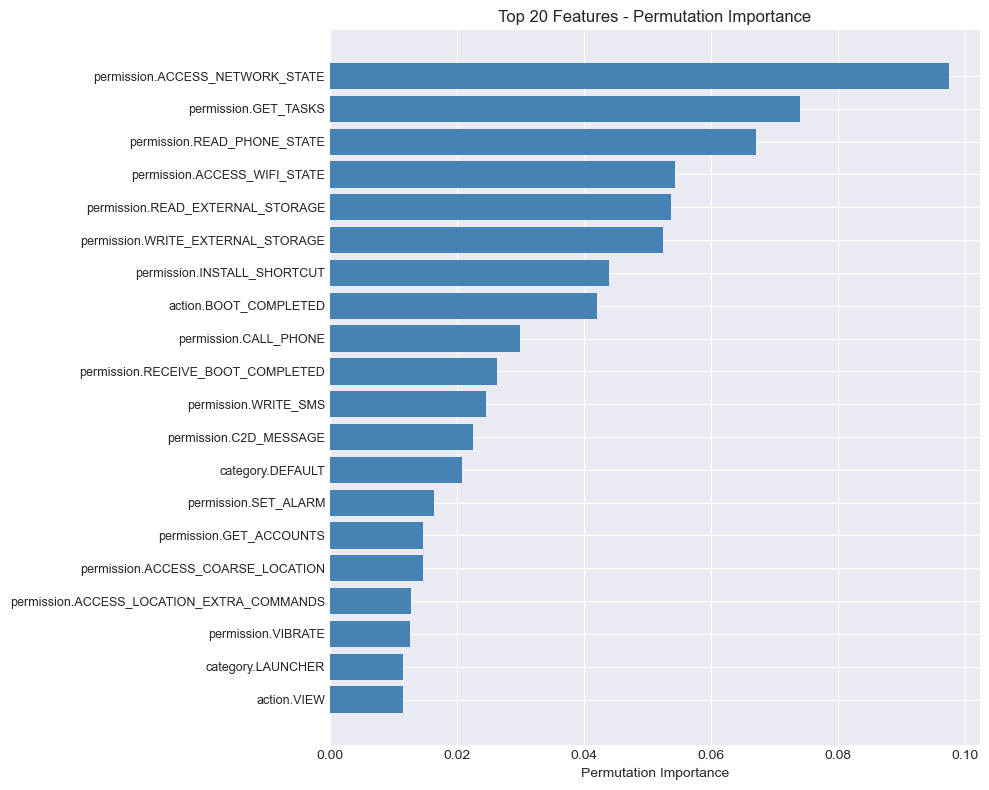

✓ Figura guardada: reports/05_feature_importance.png


In [23]:
# Permutation importance
print('Calculando Permutation Importance...')

# Wrapper para sklearn
class KerasWrapper:
    def __init__(self, model):
        self.model = model
    
    def fit(self, X, y):
        # El modelo ya está entrenado, retorna self
        return self
    
    def predict(self, X):
        return self.model.predict(X, verbose=0).argmax(axis=1)
    
    def score(self, X, y):
        return f1_score(y, self.predict(X), average='macro')

wrapper = KerasWrapper(best_model)

perm_importance = permutation_importance(
    wrapper, X_test, y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=1,
    scoring='f1_macro'
)

# Top 20 features
top_indices = np.argsort(perm_importance.importances_mean)[-20:][::-1]
top_features = [feature_names[i] for i in top_indices]
top_importances = perm_importance.importances_mean[top_indices]

print('\nTOP 20 FEATURES (Permutation Importance):')
for i, (feat, imp) in enumerate(zip(top_features, top_importances), 1):
    print(f'  {i:2d}. {feat:40s} {imp:.6f}')

# Visualizar
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(range(len(top_features)), top_importances, color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features, fontsize=9)
ax.set_xlabel('Permutation Importance')
ax.set_title('Top 20 Features - Permutation Importance')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('reports/05_feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/05_feature_importance.png')

## 15. SHAP - Explicabilidad del Modelo

Calculando SHAP values...
(Esto puede tomar 2-5 minutos)



  0%|          | 0/300 [00:00<?, ?it/s]

✓ SHAP values calculados
  Shape: (300, 345, 5)


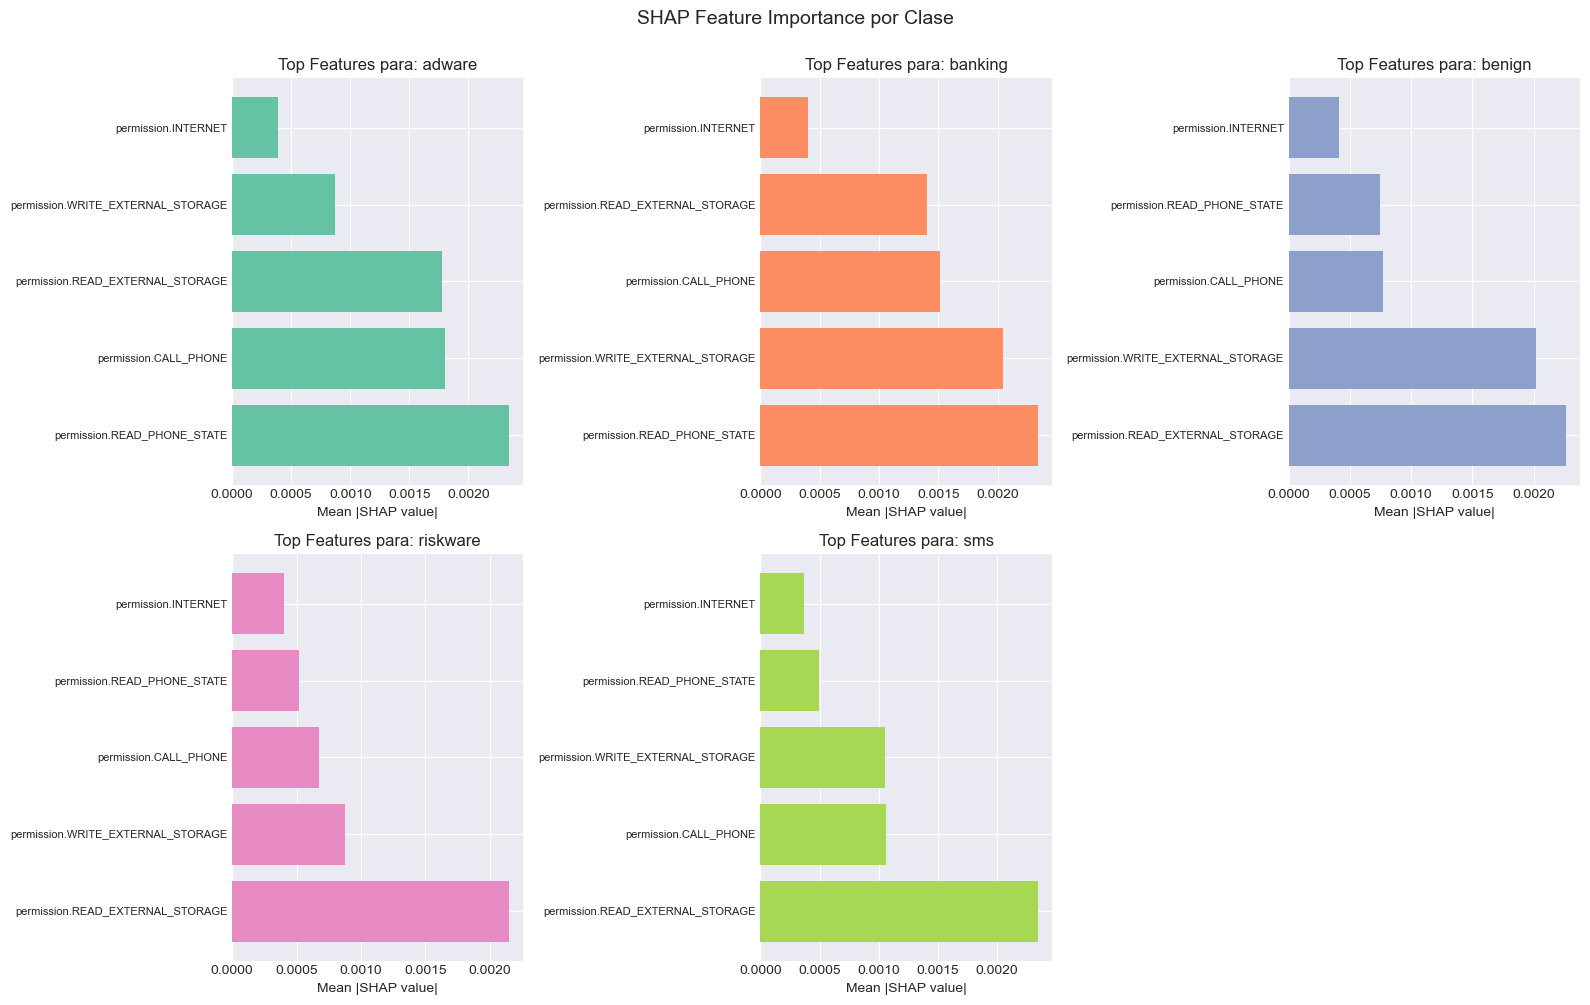

✓ Figura guardada: reports/06_shap_importance.png


In [24]:
print('Calculando SHAP values...')
print('(Esto puede tomar 2-5 minutos)\n')

# Sample de datos para SHAP (usar subsample para velocidad)
sample_size = min(300, len(X_test))
sample_indices = np.random.choice(len(X_test), sample_size, replace=False)
X_test_sample = X_test[sample_indices]

# Crear explainer SHAP
explainer = shap.KernelExplainer(
    lambda x: best_model.predict(x, verbose=0),
    shap.sample(X_test, min(100, len(X_test)), random_state=42)
)

# Calcular SHAP values
shap_values = explainer.shap_values(X_test_sample)

print('✓ SHAP values calculados')
print(f'  Shape: {np.array(shap_values).shape}')

# Visualizaciones SHAP
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for class_idx, class_name in enumerate(class_names):
    ax = axes[class_idx]
    
    if class_idx < len(shap_values):
        # Sumar SHAP values para cada feature (agregado across samples)
        mean_abs_shap = np.abs(shap_values[class_idx]).mean(axis=0)
        
        # Top 15 features
        top_idx = np.argsort(mean_abs_shap)[-15:]
        
        ax.barh(range(len(top_idx)), mean_abs_shap[top_idx], color=plt.cm.Set2(class_idx))
        ax.set_yticks(range(len(top_idx)))
        ax.set_yticklabels([feature_names[i] for i in top_idx], fontsize=8)
        ax.set_xlabel('Mean |SHAP value|')
        ax.set_title(f'Top Features para: {class_name}')
        ax.invert_yaxis()

# Ocultar último subplot
axes[5].axis('off')

plt.suptitle('SHAP Feature Importance por Clase', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig('reports/06_shap_importance.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/06_shap_importance.png')

## 16. Guardar Modelo y Metadatos

In [25]:
# Guardar modelo
best_model.save('models/best_model_mlp.h5')

# Guardar resultados en CSV
results_df = pd.DataFrame({
    'Métrica': ['Accuracy', 'Macro-F1', 'Weighted-F1', 'Micro-F1'],
    'Valor': [accuracy, macro_f1, weighted_f1, micro_f1]
})

results_df.to_csv('reports/metrics_summary.csv', index=False)

# Reporte detallado
with open('reports/evaluation_report.txt', 'w', encoding='utf-8') as f:
    f.write('='*70 + '\n')
    f.write('REPORTE TÉCNICO - DETECCIÓN DE MALWARE ANDROID (MODALIDAD TABULAR)\n')
    f.write('='*70 + '\n\n')
    
    f.write(f'Fecha: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n\n')
    
    f.write('1. ARQUITECTURA DEL MODELO\n')
    f.write('-' * 70 + '\n')
    f.write(f'Tipo: Red Neuronal Profunda (MLP)\n')
    f.write(f'Versión: {best_version}\n')
    f.write(f'Features de entrada: {n_features}\n')
    f.write(f'Clases de salida: {n_classes}\n')
    f.write(f'Optimizador: Adam\n')
    f.write(f'Loss: Sparse Categorical Crossentropy\n')
    f.write(f'Regularización: L2 + Batch Normalization + Dropout\n\n')
    
    f.write('2. MÉTRICAS DE EVALUACIÓN (TEST SET)\n')
    f.write('-' * 70 + '\n')
    f.write(f'Accuracy:      {accuracy:.6f}\n')
    f.write(f'Macro-F1:      {macro_f1:.6f} ⭐\n')
    f.write(f'Weighted-F1:   {weighted_f1:.6f}\n')
    f.write(f'Micro-F1:      {micro_f1:.6f}\n\n')
    
    f.write('3. REPORTE POR CLASE\n')
    f.write('-' * 70 + '\n')
    f.write(classification_report(y_test, y_test_pred, target_names=class_names))
    f.write('\n\n')
    
    f.write('4. TOP 20 FEATURES (Permutation Importance)\n')
    f.write('-' * 70 + '\n')
    for i, (feat, imp) in enumerate(zip(top_features, top_importances), 1):
        f.write(f'{i:2d}. {feat:40s} {imp:.6f}\n')
    f.write('\n')
    
    f.write('5. DATOS Y SPLITS\n')
    f.write('-' * 70 + '\n')
    f.write(f'Train samples:     {X_train.shape[0]}\n')
    f.write(f'Val samples:       {X_val.shape[0]}\n')
    f.write(f'Test samples:      {X_test.shape[0]}\n')
    f.write(f'Total:             {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}\n\n')
    
    f.write('6. DISTRIBUCIÓN DE CLASES (TEST)\n')
    f.write('-' * 70 + '\n')
    for class_name in class_names:
        count = (y_test == np.where(class_names == class_name)[0][0]).sum()
        pct = 100 * count / len(y_test)
        f.write(f'{class_name:15s}: {count:5d} ({pct:5.2f}%)\n')
    f.write('\n')

print('✓ Modelo guardado: models/best_model_mlp.h5')
print('✓ Métricas guardadas: reports/metrics_summary.csv')
print('✓ Reporte guardado: reports/evaluation_report.txt')

✓ Modelo guardado: models/best_model_mlp.h5
✓ Métricas guardadas: reports/metrics_summary.csv
✓ Reporte guardado: reports/evaluation_report.txt


## 17. Evaluar Robustez en Datos Adversarios y Ofuscados

Cargando datos adversarios y ofuscados...

EVALUACIÓN DE ROBUSTEZ

TEST ORIGINAL:
  Accuracy:   0.9107
  Macro-F1:   0.8925

DATA ADVERSARIO (perturbaciones):
  Accuracy:   0.2258 (drop: +75.20%)
  Macro-F1:   0.0737 (drop: +91.74%)

DATA OFUSCADO (código ofuscado):
  Accuracy:   0.8911 (drop: +2.15%)
  Macro-F1:   0.8638 (drop: +3.21%)

✓ Resultados de robustez guardados: reports/robustness_evaluation.csv


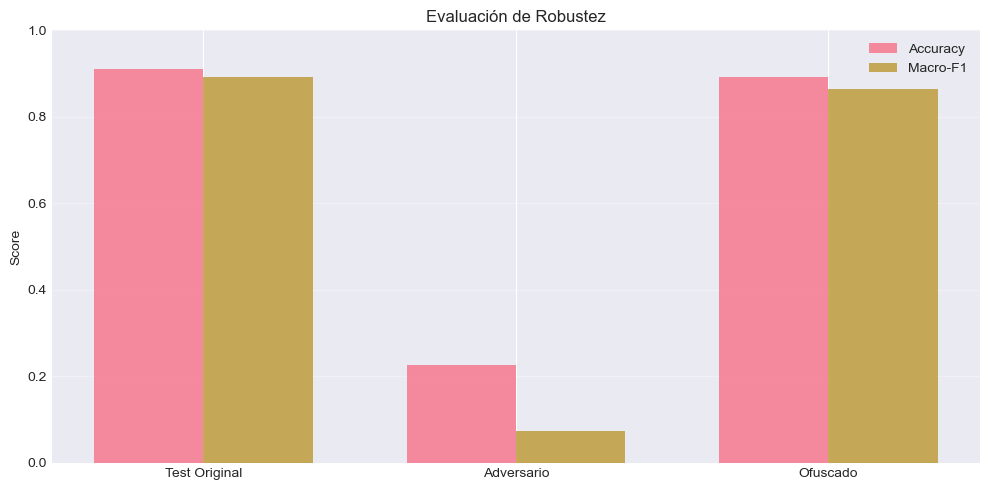

✓ Figura guardada: reports/07_robustness_comparison.png


In [26]:
# Cargar scaler y label encoder
with open('models/scaler.pkl', 'rb') as f:
    scaler = pickle.load(f)

with open('models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

# Cargar datos adversarios
data_path = 'Multimodal_CIC-MalDroid2020/Tabular/'

print('Cargando datos adversarios y ofuscados...')
df_adv = pd.read_csv(f'{data_path}adv-tabular.csv')
df_obfus = pd.read_csv(f'{data_path}obfus-tabular.csv')

# Features usadas
used_features = metadata['feature_names']

# Preprocesar adversarios
X_adv = df_adv[used_features].values
X_adv_scaled = scaler.transform(X_adv)
y_adv = le.transform(df_adv['Class'].values)

# Preprocesar ofuscados
X_obfus = df_obfus[used_features].values
X_obfus_scaled = scaler.transform(X_obfus)
y_obfus = le.transform(df_obfus['Class'].values)

# Evaluar
y_adv_pred = best_model.predict(X_adv_scaled, verbose=0).argmax(axis=1)
y_obfus_pred = best_model.predict(X_obfus_scaled, verbose=0).argmax(axis=1)

macro_f1_adv = f1_score(y_adv, y_adv_pred, average='macro')
macro_f1_obfus = f1_score(y_obfus, y_obfus_pred, average='macro')
accuracy_adv = accuracy_score(y_adv, y_adv_pred)
accuracy_obfus = accuracy_score(y_obfus, y_obfus_pred)

print('\n' + '='*60)
print('EVALUACIÓN DE ROBUSTEZ')
print('='*60)
print('\nTEST ORIGINAL:')
print(f'  Accuracy:   {accuracy:.4f}')
print(f'  Macro-F1:   {macro_f1:.4f}')

print('\nDATA ADVERSARIO (perturbaciones):')
print(f'  Accuracy:   {accuracy_adv:.4f} (drop: {100*(accuracy - accuracy_adv)/accuracy:+.2f}%)')
print(f'  Macro-F1:   {macro_f1_adv:.4f} (drop: {100*(macro_f1 - macro_f1_adv)/macro_f1:+.2f}%)')

print('\nDATA OFUSCADO (código ofuscado):')
print(f'  Accuracy:   {accuracy_obfus:.4f} (drop: {100*(accuracy - accuracy_obfus)/accuracy:+.2f}%)')
print(f'  Macro-F1:   {macro_f1_obfus:.4f} (drop: {100*(macro_f1 - macro_f1_obfus)/macro_f1:+.2f}%)')

# Guardar resultados robustez
robustness_df = pd.DataFrame({
    'Dataset': ['Test Original', 'Adversario', 'Ofuscado'],
    'Accuracy': [accuracy, accuracy_adv, accuracy_obfus],
    'Macro-F1': [macro_f1, macro_f1_adv, macro_f1_obfus],
    'Samples': [len(y_test), len(y_adv), len(y_obfus)]
})

robustness_df.to_csv('reports/robustness_evaluation.csv', index=False)
print('\n✓ Resultados de robustez guardados: reports/robustness_evaluation.csv')

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(len(robustness_df))
width = 0.35

ax.bar(x_pos - width/2, robustness_df['Accuracy'], width, label='Accuracy', alpha=0.8)
ax.bar(x_pos + width/2, robustness_df['Macro-F1'], width, label='Macro-F1', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Evaluación de Robustez')
ax.set_xticks(x_pos)
ax.set_xticklabels(robustness_df['Dataset'])
ax.legend()
ax.grid(alpha=0.3, axis='y')
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('reports/07_robustness_comparison.png', dpi=100, bbox_inches='tight')
plt.show()
print('✓ Figura guardada: reports/07_robustness_comparison.png')

## 18. Resumen Final y Recomendaciones

In [27]:
print('\n' + '='*70)
print('RESUMEN FINAL - PIPELINE TABULAR COMPLETO')
print('='*70)

print('\n1. PREPROCESAMIENTO')
print('-' * 70)
print(f'  ✓ Features originales: 400')
print(f'  ✓ Features finales: {n_features} (reducción: {100*(400-n_features)/400:.1f}%)')
print(f'  ✓ Eliminadas: {400 - n_features} (constantes + correlación alta)')

print('\n2. MODELO ENTRENADO')
print('-' * 70)
print(f'  ✓ Arquitectura: Red Neuronal ({best_version})')
print(f'  ✓ Capas: 4 densas + BatchNormalization + Dropout')
print(f'  ✓ Parámetros: ~{best_model.count_params():,}')

print('\n3. PERFORMANCE (TEST SET)')
print('-' * 70)
print(f'  ✓ Accuracy:    {accuracy:.4f}')
print(f'  ✓ Macro-F1:    {macro_f1:.4f} ⭐ MÉTRICA PRINCIPAL')
print(f'  ✓ Weighted-F1: {weighted_f1:.4f}')

print('\n4. INTERPRETABILIDAD')
print('-' * 70)
print(f'  ✓ Feature Importance calculada (Permutation)')
print(f'  ✓ SHAP values calculados para todas las clases')
print(f'  ✓ Top 20 features identificados')

print('\n5. ROBUSTEZ')
print('-' * 70)
print(f'  ✓ Test Original:     Macro-F1 = {macro_f1:.4f}')
print(f'  ✓ Data Adversario:   Macro-F1 = {macro_f1_adv:.4f} (drop: {100*(macro_f1 - macro_f1_adv)/macro_f1:.2f}%)')
print(f'  ✓ Data Ofuscado:     Macro-F1 = {macro_f1_obfus:.4f} (drop: {100*(macro_f1 - macro_f1_obfus)/macro_f1:.2f}%)')

print('\n6. ARCHIVOS GENERADOS')
print('-' * 70)
files_generated = [
    'models/best_model_mlp.h5',
    'models/scaler.pkl',
    'models/label_encoder.pkl',
    'data/processed/X_train_scaled.npy',
    'data/processed/X_val_scaled.npy',
    'data/processed/X_test_scaled.npy',
    'reports/metrics_summary.csv',
    'reports/evaluation_report.txt',
    'reports/robustness_evaluation.csv',
    'reports/01_correlation_matrix.png',
    'reports/02_pca_analysis.png',
    'reports/03_training_curves.png',
    'reports/04_confusion_matrix.png',
    'reports/05_feature_importance.png',
    'reports/06_shap_importance.png',
    'reports/07_robustness_comparison.png'
]

for f in files_generated:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f'  ✓ {f:45s} ({size_kb:8.1f} KB)')

print('\n' + '='*70)
print('✓ PIPELINE COMPLETADO EXITOSAMENTE')
print('='*70)


RESUMEN FINAL - PIPELINE TABULAR COMPLETO

1. PREPROCESAMIENTO
----------------------------------------------------------------------
  ✓ Features originales: 400
  ✓ Features finales: 345 (reducción: 13.8%)
  ✓ Eliminadas: 55 (constantes + correlación alta)

2. MODELO ENTRENADO
----------------------------------------------------------------------
  ✓ Arquitectura: Red Neuronal (V1)
  ✓ Capas: 4 densas + BatchNormalization + Dropout
  ✓ Parámetros: ~131,589

3. PERFORMANCE (TEST SET)
----------------------------------------------------------------------
  ✓ Accuracy:    0.9107
  ✓ Macro-F1:    0.8925 ⭐ MÉTRICA PRINCIPAL
  ✓ Weighted-F1: 0.9118

4. INTERPRETABILIDAD
----------------------------------------------------------------------
  ✓ Feature Importance calculada (Permutation)
  ✓ SHAP values calculados para todas las clases
  ✓ Top 20 features identificados

5. ROBUSTEZ
----------------------------------------------------------------------
  ✓ Test Original:     Macro-F1 = 0.892